In [9]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from requests.packages import target


def wine_rule_based(alcohol):
    if 12 > alcohol:
        return 0
    elif 12 < alcohol < 13:
        return 1
    elif alcohol > 13:
        return 2


def plot_decision_boundary(X, y, model, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
                edgecolor='k', s=40, linewidths=0.8)

    ax.set_title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
Fit time : 0.0012 s
Predict time: 0.0024 s
accuracy KNN without PCA: 
 0.9629629629629629

Fit time : 0.0011 s
Predict time: 0.0029 s
accuracy KNN with PCA: 
 0.9814814814814815

accuracy Rule-Based: 
 0.35185185185185186

Euclidean:   0.9630
Manhattan:   0.9630
Cosine:      0.9815
Chebyshev:   0.9444
Mahalanobis: 0.9074


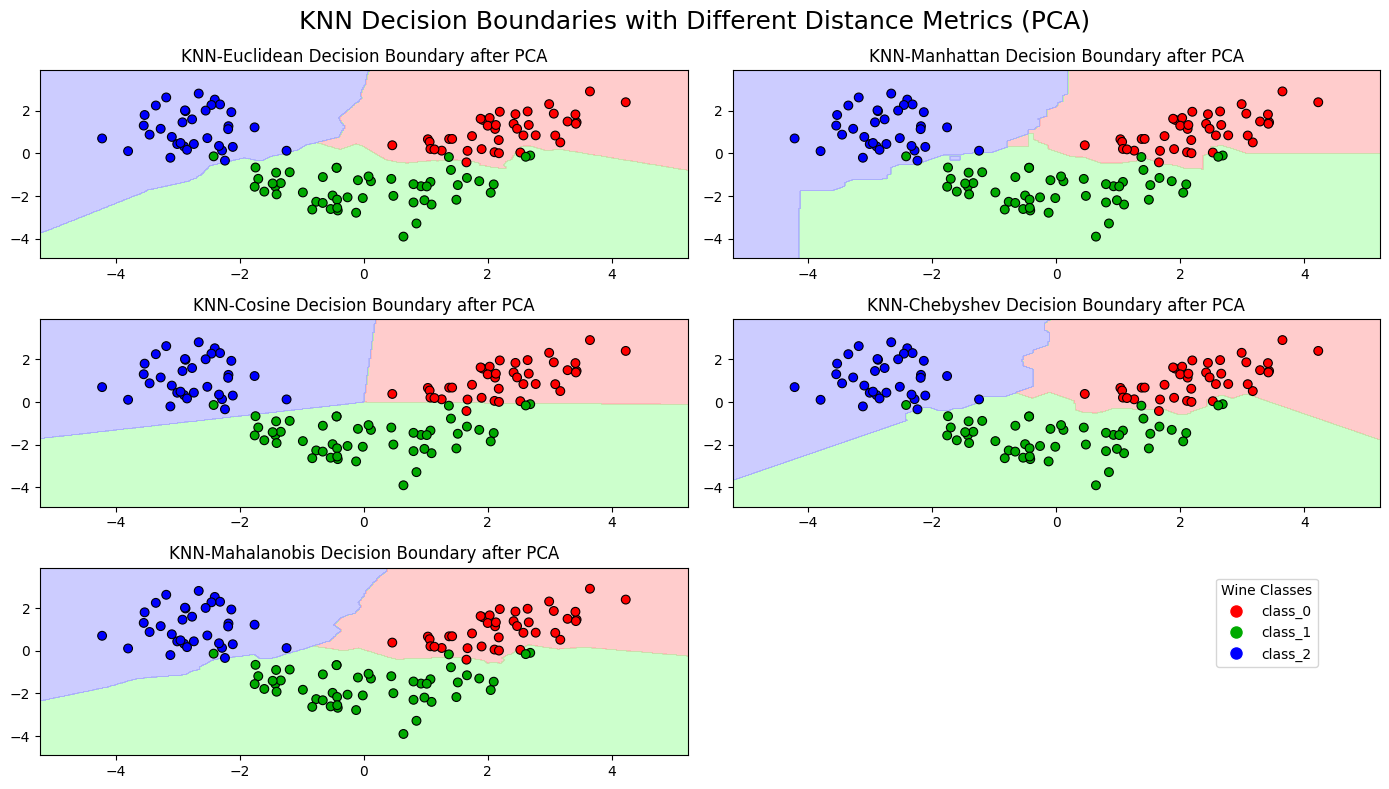

In [10]:
from sklearn.datasets import load_wine
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

load_wine = load_wine()
x = load_wine.data
y = load_wine.target
print(x)
wine_df = pd.DataFrame(data=x, columns=load_wine.feature_names)
wine_df['class'] = y

# split dataset
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
# scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
t0 = time.perf_counter()
knn.fit(x_train_scaled, y_train)
fit_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred = knn.predict(x_test_scaled)
pred_time = time.perf_counter() - t0

print(f"Fit time : {fit_time:.4f} s")
print(f"Predict time: {pred_time:.4f} s")
print('accuracy KNN without PCA: \n', accuracy_score(y_test, y_pred), end='\n\n')

## 2.PCA
pca = PCA(n_components=2)
x_train_scaled_pca = pca.fit_transform(x_train_scaled)
x_test_scaled_pca = pca.transform(x_test_scaled)

t0 = time.perf_counter()
knn.fit(x_train_scaled_pca, y_train)
fit_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred = knn.predict(x_test_scaled_pca)
pred_time = time.perf_counter() - t0

print(f"Fit time : {fit_time:.4f} s")
print(f"Predict time: {pred_time:.4f} s")
print('accuracy KNN with PCA: \n', accuracy_score(y_test, y_pred), end='\n\n')

## 3.Rule-Based
y_pred = list(map(wine_rule_based, x_test_scaled[:, 0]))
print('accuracy Rule-Based: \n', accuracy_score(y_test, y_pred), end='\n\n')

## 4.Distance-Metrics

# Euclidean
knn_euclidean = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_euclidean.fit(x_train_scaled, y_train)
y_pred_euclidean = knn_euclidean.predict(x_test_scaled)

# Manhattan
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_manhattan.fit(x_train_scaled, y_train)
y_pred_manhattan = knn_manhattan.predict(x_test_scaled)

# Cosine
knn_cosine = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn_cosine.fit(x_train_scaled, y_train)
y_pred_cosine = knn_cosine.predict(x_test_scaled)

# Chebyshev
knn_chebyshev = KNeighborsClassifier(n_neighbors=3, metric='chebyshev')
knn_chebyshev.fit(x_train_scaled, y_train)
y_pred_chebyshev = knn_chebyshev.predict(x_test_scaled)

# Mahalanobis
cov = np.cov(x_train_scaled, rowvar=False)
inv_cov = np.linalg.inv(cov)

knn_mahalanobis = KNeighborsClassifier(n_neighbors=3, metric='mahalanobis', metric_params={'VI': inv_cov})
knn_mahalanobis.fit(x_train_scaled, y_train)
y_pred_mahalanobis = knn_mahalanobis.predict(x_test_scaled)

acc_euclidean = accuracy_score(y_test, y_pred_euclidean)
acc_manhattan = accuracy_score(y_test, y_pred_manhattan)
acc_cosine = accuracy_score(y_test, y_pred_cosine)
acc_chebyshev = accuracy_score(y_test, y_pred_chebyshev)
acc_mahalanobis = accuracy_score(y_test, y_pred_mahalanobis)

print(f"Euclidean:   {acc_euclidean:.4f}")
print(f"Manhattan:   {acc_manhattan:.4f}")
print(f"Cosine:      {acc_cosine:.4f}")
print(f"Chebyshev:   {acc_chebyshev:.4f}")
print(f"Mahalanobis: {acc_mahalanobis:.4f}")

## 4. Decision Boundary
fig, ax = plt.subplots(3, 2, figsize=(14, 8))
ax = ax.ravel()

models = {
    'euclidean': 'KNN-Euclidean Decision Boundary after PCA',
    'manhattan': 'KNN-Manhattan Decision Boundary after PCA',
    'cosine': 'KNN-Cosine Decision Boundary after PCA',
    'chebyshev': 'KNN-Chebyshev Decision Boundary after PCA',
    'mahalanobis': 'KNN-Mahalanobis Decision Boundary after PCA',
}

for i, (metric, title) in enumerate(models.items()):
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric)
    if metric == 'mahalanobis':
        cov = np.cov(x_train_scaled_pca, rowvar=False)
        inv_cov = np.linalg.inv(cov)
        knn = KNeighborsClassifier(n_neighbors=3, metric=metric, metric_params={'VI': inv_cov})

    knn.fit(x_train_scaled_pca, y_train)
    plot_decision_boundary(X=x_train_scaled_pca, y=y_train, model=knn, title=title, ax=ax[i])

target_names = load_wine.target_names
cmap_bold = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=target_names[i],
               markerfacecolor=cmap_bold.colors[i % len(cmap_bold.colors)],
               markersize=10)
    for i in range(len(target_names))
]

# Position legend in the bottom-right of the figure
fig.legend(handles=legend_elements, title='Wine Classes',
           loc='lower right', bbox_to_anchor=(0.95, 0.15))

fig.delaxes(ax[5])
plt.suptitle("KNN Decision Boundaries with Different Distance Metrics (PCA)", fontsize=18)
plt.tight_layout()
plt.show();